# Lecture 12: Table Practice...more with Skyscrapers and Bike Sharing
v.ekc

No new table methods today--horray!!!! Instead, the full toolkit on real data: finishing the skyscraper activity, then a deep dive into a Bay Area bike-share dataset.

We will practice a full pipeline: load → filter → group/pivot → join → map analysis on 350k rows 😵‍💫

**Today's sections:**
1. Skyscrapers, finished
2. Another join example
3. Bike sharing — distributions of durations
4. Start and end stations
5. Try It — fastest trips
6. Maps

In [1]:
from datascience import *
%matplotlib inline
path_data = '../../../assets/data/'
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import numpy as np
import warnings
warnings.filterwarnings("ignore")


---
## 1. 🗼 Skyscrapers, Finished

Try It #1 from yesterday is worked below; questions 2 and 3 are yours to try! We might have gone over this last lecture if we had time...

In [2]:
# From the CORGIS Dataset Project
# By Austin Cory Bart acbart@vt.edu
# Version 2.0.0, created 3/22/2016
# https://corgis-edu.github.io/corgis/csv/skyscrapers/

sky = Table.read_table('skyscrapers.csv')
sky = (sky.with_column('age', 2024 - sky.column('completed'))
          .drop('completed'))
sky.show(3)

name,material,city,height,age
One World Trade Center,mixed/composite,New York City,541.3,10
Willis Tower,steel,Chicago,442.14,50
432 Park Avenue,concrete,New York City,425.5,9


1. For each city, what’s the height of the tallest building for each material?

In [3]:
# 1. For each city, what’s the height of the tallest building for each material?

sky.pivot('material','city',values = 'height',collect = max)

city,concrete,mixed/composite,steel
Atlanta,264.25,311.8,169.47
Austin,208.15,0,93.6
Baltimore,161.24,0,155.15
Boston,121.92,139,240.79
Charlotte,265.48,239.7,179.23
Chicago,423.22,306.94,442.14
Cincinnati,125,202.69,175
Cleveland,125,288.65,215.8
Columbus,79.25,0,169.3
Dallas,176.48,280.72,270.06


2. For each city, what’s the height difference between the tallest steel building and the tallest concrete building?

In [8]:
# 2. For each city, what’s the height difference between the tallest 
#    steel building and the tallest concrete building?

tallest = sky.pivot('material', 'city', values='height', collect=max)
tallest.with_column(
    'difference',
    abs(tallest.column('steel') - tallest.column('concrete')))

city,concrete,mixed/composite,steel,difference
Atlanta,264.25,311.8,169.47,94.78
Austin,208.15,0,93.6,114.55
Baltimore,161.24,0,155.15,6.09001
Boston,121.92,139,240.79,118.87
Charlotte,265.48,239.7,179.23,86.25
Chicago,423.22,306.94,442.14,18.92
Cincinnati,125,202.69,175,50
Cleveland,125,288.65,215.8,90.8
Columbus,79.25,0,169.3,90.05
Dallas,176.48,280.72,270.06,93.58


3. Generate a table of the names of the oldest buildings for each material for each city:

In [16]:
# 3. Generate a table of the names of the oldest buildings for each 
#    material for each city:

# Hint: You can use sort to find the name of the oldest building in the dataset
sky.sort('age', descending=True)#.column('name').item(0)

# Hint: Perhaps create your own custom function which you can use to aggregate the values by position???

# Put your solution here




name,material,city,height,age
Statue of Liberty,steel,New York City,93,138
The Rookery,steel,Chicago,55.02,136
Wainwright Building,steel,St. Louis,44.81,132
Park Place Tower,steel,New York City,88.7,129
Reliance Building,steel,Chicago,61.47,129
Bank of Tokyo Building,steel,New York City,103,128
FlatironCity,steel,Atlanta,48.2,127
Ferry Building,steel,San Francisco,74.68,126
Park Row Building,steel,New York City,119.18,125
6 North Michigan,steel,Chicago,85.95,125


<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*Same pivot pattern as question 1, different `values`/`collect`.*

```python
# 2.
tallest = sky.pivot('material', 'city', values='height', collect=max)
tallest.with_column(
    'difference',
    abs(tallest.column('steel') - tallest.column('concrete')))

# 3.
def first(s):
    return s.item(0)

sky.sort('age').pivot('material', 'city', values='name', collect=first)
```

</details>

---
## 2. Another Join Example

Remember the census codes (0/1/2)? A tiny **code table** plus a join makes them readable, a very common real-world move.

In [17]:
full = Table.read_table('nc-est2019-agesex-res.csv')
census = full.select('SEX', 'AGE', 'POPESTIMATE2019')
census.show(3)

SEX,AGE,POPESTIMATE2019
0,0,3783052
0,1,3829599
0,2,3922044


In [18]:
sex_codes = Table().with_columns(
    'SEX CODE', make_array(0, 1, 2),
    'CODE DEFINITION', make_array('All', 'Selected Male', 'Selected Female')
)
sex_codes

SEX CODE,CODE DEFINITION
0,All
1,Selected Male
2,Selected Female


In [6]:
census.join('SEX', sex_codes, 'SEX CODE').sort('AGE').show(6)

SEX,AGE,POPESTIMATE2019,CODE DEFINITION
0,0,3783052,All
1,0,1935117,Selected Male
2,0,1847935,Selected Female
0,1,3829599,All
1,1,1958585,Selected Male
2,1,1871014,Selected Female


### Try It 1: Check the join 😊

1. How many rows does the joined table have, compared to `census`? Check with code.

2. Why does that make sense here, and when would a join have *fewer* rows?

In [ ]:
# 1. row counts


*2. Your interpretation: (double-click to edit)*

<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*Every SEX value (0/1/2) matches exactly one code row, a perfect 1-to-1 join.*

```python
# 1.
census.join('SEX', sex_codes, 'SEX CODE').num_rows, census.num_rows
```

*2. Equal counts because every row found exactly one match; rows with no match would be silently dropped: that's when joins shrink.*

</details>

---
## 3. Bike Sharing 🚲

~350,000 bike trips in the SF Bay Area. Big data needs the histogram + filter combo:

In [19]:
trip = Table.read_table('trip.csv')
trip.show(3)

Trip ID,Duration,Start Date,Start Station,Start Terminal,End Date,End Station,End Terminal,Bike #,Subscriber Type,Zip Code
913460,765,8/31/2015 23:26,Harry Bridges Plaza (Ferry Building),50,8/31/2015 23:39,San Francisco Caltrain (Townsend at 4th),70,288,Subscriber,2139
913459,1036,8/31/2015 23:11,San Antonio Shopping Center,31,8/31/2015 23:28,Mountain View City Hall,27,35,Subscriber,95032
913455,307,8/31/2015 23:13,Post at Kearny,47,8/31/2015 23:18,2nd at South Park,64,468,Subscriber,94107


### Distribution of Durations

The raw histogram is useless, a few *very* long rentals squash everything. Filter to commutes (under 30 min) first.

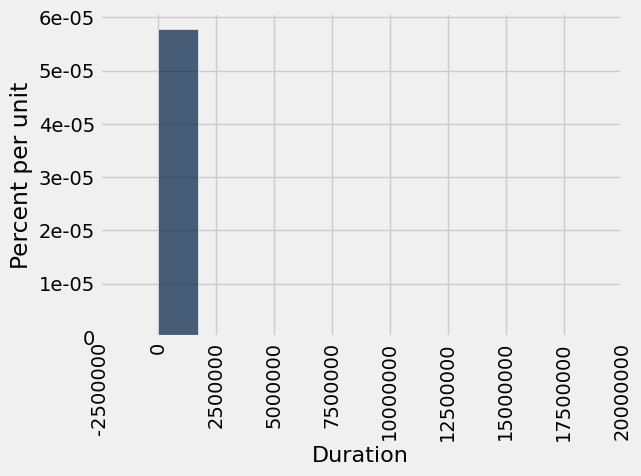

In [20]:
trip.hist('Duration')

In [21]:
trip.sort('Duration', descending=True)

Trip ID,Duration,Start Date,Start Station,Start Terminal,End Date,End Station,End Terminal,Bike #,Subscriber Type,Zip Code
568474,17270400,12/6/2014 21:59,South Van Ness at Market,66,6/24/2015 20:18,2nd at Folsom,62,535,Customer,95531
825850,2137000,6/28/2015 21:50,Market at Sansome,77,7/23/2015 15:27,Yerba Buena Center of the Arts (3rd @ Howard),68,466,Customer,97213
750192,1852590,5/2/2015 6:17,San Antonio Shopping Center,31,5/23/2015 16:53,Castro Street and El Camino Real,32,680,Subscriber,94024
841176,1133540,7/10/2015 10:35,University and Emerson,35,7/23/2015 13:27,University and Emerson,35,262,Customer,94306
522337,720454,10/30/2014 8:29,Redwood City Caltrain Station,22,11/7/2014 15:36,Stanford in Redwood City,25,692,Customer,94010
774999,688899,5/20/2015 15:27,Palo Alto Caltrain Station,34,5/28/2015 14:49,California Ave Caltrain Station,36,230,Customer,nil
635260,655939,2/8/2015 3:05,San Jose Civic Center,3,2/15/2015 17:17,SJSU 4th at San Carlos,12,132,Customer,89451
745640,611240,4/29/2015 9:41,University and Emerson,35,5/6/2015 11:28,San Antonio Shopping Center,31,196,Customer,81
635263,602338,2/8/2015 3:09,San Jose Civic Center,3,2/15/2015 2:28,San Jose Civic Center,3,9,Customer,89451
779645,594550,5/24/2015 13:33,San Pedro Square,6,5/31/2015 10:42,San Pedro Square,6,39,Customer,95118


Filter to commutes (under 30 minutes), then look again:

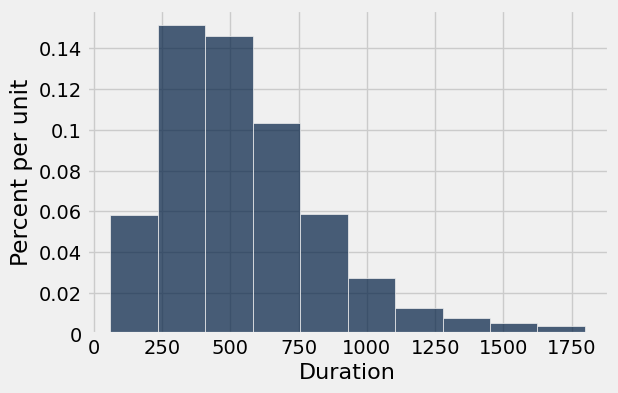

In [22]:
commute = trip.where('Duration', are.below(1800))
commute.hist('Duration')

# we can add units!
# commute.hist('Duration', bins=np.arange(0, 1800, 250), unit='Second')

Area Principle check: estimate the `[250, 500)` share from the bar first:

In [25]:
# Approx percent of people who have 
# a ride duration between 250 and 500 seconds
# "between" = [250, 500) 

(500-250) * 0.15 

37.5

In [24]:
commute.where('Duration', are.between(250, 500)).num_rows

129079

Now the exact count, as a fraction of all commutes:

In [26]:
commute.num_rows

338343

In [35]:
between_250_500 = commute.where('Duration', are.between(250, 500)).num_rows

between_250_500 / commute.num_rows

0.38150338561755376

> **Area check:** the `[250, 500)` bar has height ≈ 0.15 %/second × 250 seconds ≈ 38%, and counting rows directly gives 129,079/338,343 ≈ 38%. Just making sure the Area Principle works.

Two more views, the same 250-second bins again, then 60 automatic bins:

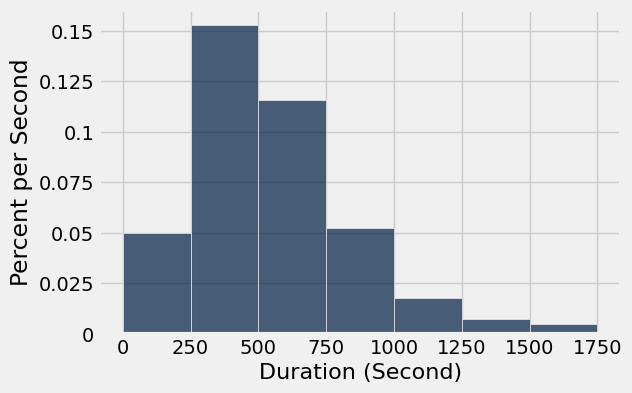

In [33]:
commute.hist('Duration', bins=np.arange(0, 1800, 250), unit='Second')

# Change the bins
# commute.hist('Duration', bins=60, unit='Second')

### Try It 2: Short rides 😊

1. Draw the histogram of rides **under 10 minutes** (600 seconds) with 60-second bins.

2. What exact fraction of commute rides last between 500 and 750 seconds?

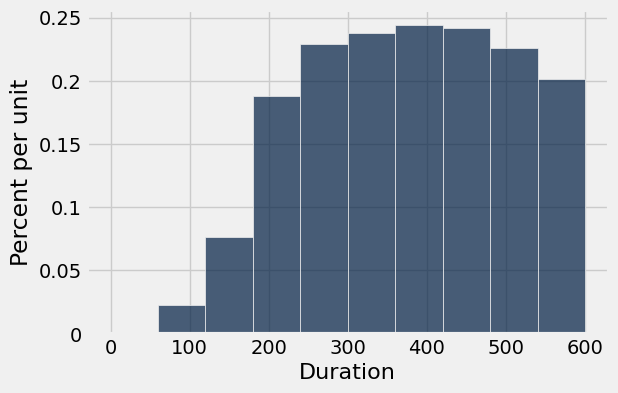

In [39]:
# 1. under-600s histogram, 60s bins



In [ ]:
# 2. fraction in [500, 750)



<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*Filter, then bin; count, then divide.*

```python
# 1.
commute.where('Duration', are.below(600)).hist('Duration', bins=np.arange(0, 601, 60), unit='Second')

# 2.
commute.where('Duration', are.between(500, 750)).num_rows / commute.num_rows
```

</details>

---
## 4. Start and End Stations

`group` for the most popular start, `pivot` for the full station-to-station grid.

In [40]:
# Most common start station

starts = commute.group('Start Station').sort('count', descending=True)
starts

Start Station,count
San Francisco Caltrain (Townsend at 4th),25858
San Francisco Caltrain 2 (330 Townsend),21523
Harry Bridges Plaza (Ferry Building),15543
Temporary Transbay Terminal (Howard at Beale),14298
2nd at Townsend,13674
Townsend at 7th,13579
Steuart at Market,13215
Embarcadero at Sansome,12842
Market at 10th,11523
Market at Sansome,11023


In [41]:
# Number of trips between stations

commute.pivot('Start Station', 'End Station')

End Station,2nd at Folsom,2nd at South Park,2nd at Townsend,5th at Howard,Adobe on Almaden,Arena Green / SAP Center,Beale at Market,Broadway St at Battery St,California Ave Caltrain Station,Castro Street and El Camino Real,Civic Center BART (7th at Market),Clay at Battery,Commercial at Montgomery,Cowper at University,Davis at Jackson,Embarcadero at Bryant,Embarcadero at Folsom,Embarcadero at Sansome,Embarcadero at Vallejo,Evelyn Park and Ride,Franklin at Maple,Golden Gate at Polk,Grant Avenue at Columbus Avenue,Harry Bridges Plaza (Ferry Building),Howard at 2nd,Japantown,MLK Library,Market at 10th,Market at 4th,Market at Sansome,Mechanics Plaza (Market at Battery),Mezes Park,Mountain View Caltrain Station,Mountain View City Hall,Palo Alto Caltrain Station,Park at Olive,Paseo de San Antonio,Post at Kearny,Powell Street BART,Powell at Post (Union Square),Redwood City Caltrain Station,Redwood City Medical Center,Redwood City Public Library,Rengstorff Avenue / California Street,Ryland Park,SJSU - San Salvador at 9th,SJSU 4th at San Carlos,San Antonio Caltrain Station,San Antonio Shopping Center,San Francisco Caltrain (Townsend at 4th),San Francisco Caltrain 2 (330 Townsend),San Francisco City Hall,San Jose City Hall,San Jose Civic Center,San Jose Diridon Caltrain Station,San Mateo County Center,San Pedro Square,San Salvador at 1st,Santa Clara County Civic Center,Santa Clara at Almaden,South Van Ness at Market,Spear at Folsom,St James Park,Stanford in Redwood City,Steuart at Market,Temporary Transbay Terminal (Howard at Beale),Townsend at 7th,University and Emerson,Washington at Kearny,Yerba Buena Center of the Arts (3rd @ Howard)
2nd at Folsom,54,190,554,107,0,0,40,21,0,0,44,78,54,0,9,77,32,41,14,0,0,11,30,416,53,0,0,169,114,302,33,0,0,0,0,0,0,60,121,88,0,0,0,0,0,0,0,0,0,694,445,21,0,0,0,0,0,0,0,0,38,57,0,0,39,237,342,0,17,31
2nd at South Park,295,164,71,180,0,0,208,85,0,0,112,87,160,0,37,56,178,83,116,0,0,57,73,574,500,0,0,139,199,1633,119,0,0,0,0,0,0,299,84,113,0,0,0,0,0,0,0,0,0,559,480,48,0,0,0,0,0,0,0,0,66,152,0,0,374,429,143,0,63,209
2nd at Townsend,437,151,185,92,0,0,608,350,0,0,80,329,168,0,386,361,658,506,254,0,0,27,315,2607,295,0,0,110,225,845,177,0,0,0,0,0,0,120,100,141,0,0,0,0,0,0,0,0,0,905,299,14,0,0,0,0,0,0,0,0,72,508,0,0,2349,784,417,0,57,166
5th at Howard,113,177,148,83,0,0,59,130,0,0,203,76,129,0,30,57,49,166,54,0,0,85,78,371,478,0,0,303,158,168,90,0,0,0,0,0,0,93,183,169,0,0,0,0,0,0,0,0,0,690,1859,48,0,0,0,0,0,0,0,0,116,102,0,0,182,750,200,0,43,267
Adobe on Almaden,0,0,0,0,11,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,17,7,0,0,0,0,0,0,0,0,0,25,0,0,0,0,0,0,0,7,7,16,0,0,0,0,0,19,23,265,0,20,4,5,10,0,0,14,0,0,0,0,0,0,0
Arena Green / SAP Center,0,0,0,0,7,64,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,16,5,0,0,0,0,0,0,0,0,0,21,0,0,0,0,0,0,0,24,3,7,0,0,0,0,0,6,20,7,0,56,12,38,259,0,0,13,0,0,0,0,0,0,0
Beale at Market,127,79,183,59,0,0,59,661,0,0,201,75,101,0,247,178,38,590,165,0,0,54,435,57,72,0,0,286,236,163,26,0,0,0,0,0,0,49,227,179,0,0,0,0,0,0,0,0,0,640,269,25,0,0,0,0,0,0,0,0,243,128,0,0,16,167,35,0,64,45
Broadway St at Battery St,67,89,279,119,0,0,1022,110,0,0,62,283,226,0,191,198,79,231,35,0,0,5,70,168,49,0,0,32,97,341,214,0,0,0,0,0,0,169,71,218,0,0,0,0,0,0,0,0,0,685,438,7,0,0,0,0,0,0,0,0,18,106,0,0,344,748,50,0,79,47
California Ave Caltrain Station,0,0,0,0,0,0,0,0,38,1,0,0,0,29,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,192,40,0,0,0,0,0,0,0,6,0,0,0,17,10,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,57,0,0
Castro Street and El Camino Real,0,0,0,0,0,0,0,0,0,30,0,0,0,0,0,0,0,0,0,14,0,0,0,0,0,0,0,0,0,0,0,0,931,34,0,0,0,0,0,0,0,0,0,7,0,0,0,4,12,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Average durations of trips between stations

commute.pivot('Start Station', 'End Station', values='Duration', collect=np.average)

---
### Try It 3: Fastest trips 😊

1. Find the fastest trip ever between each pair of stations.

2. Estimate the 5 stations closest to Civic Center BART by finding the minimum trip time. *Hint: it's listed as `Civic Center BART (7th at Market)`; `are.containing` saves typing.*

In [44]:
# Fill in the blank: replace the ... 
shortest = ...
shortest

End Station,2nd at Folsom,2nd at South Park,2nd at Townsend,5th at Howard,Adobe on Almaden,Arena Green / SAP Center,Beale at Market,Broadway St at Battery St,California Ave Caltrain Station,Castro Street and El Camino Real,Civic Center BART (7th at Market),Clay at Battery,Commercial at Montgomery,Cowper at University,Davis at Jackson,Embarcadero at Bryant,Embarcadero at Folsom,Embarcadero at Sansome,Embarcadero at Vallejo,Evelyn Park and Ride,Franklin at Maple,Golden Gate at Polk,Grant Avenue at Columbus Avenue,Harry Bridges Plaza (Ferry Building),Howard at 2nd,Japantown,MLK Library,Market at 10th,Market at 4th,Market at Sansome,Mechanics Plaza (Market at Battery),Mezes Park,Mountain View Caltrain Station,Mountain View City Hall,Palo Alto Caltrain Station,Park at Olive,Paseo de San Antonio,Post at Kearny,Powell Street BART,Powell at Post (Union Square),Redwood City Caltrain Station,Redwood City Medical Center,Redwood City Public Library,Rengstorff Avenue / California Street,Ryland Park,SJSU - San Salvador at 9th,SJSU 4th at San Carlos,San Antonio Caltrain Station,San Antonio Shopping Center,San Francisco Caltrain (Townsend at 4th),San Francisco Caltrain 2 (330 Townsend),San Francisco City Hall,San Jose City Hall,San Jose Civic Center,San Jose Diridon Caltrain Station,San Mateo County Center,San Pedro Square,San Salvador at 1st,Santa Clara County Civic Center,Santa Clara at Almaden,South Van Ness at Market,Spear at Folsom,St James Park,Stanford in Redwood City,Steuart at Market,Temporary Transbay Terminal (Howard at Beale),Townsend at 7th,University and Emerson,Washington at Kearny,Yerba Buena Center of the Arts (3rd @ Howard)
2nd at Folsom,61,97,164,268,0,0,271,407,0,0,483,329,306,0,494,239,262,687,599,0,0,639,416,282,80,0,0,506,237,167,250,0,0,0,0,0,0,208,264,290,0,0,0,0,0,0,0,0,0,300,303,584,0,0,0,0,0,0,0,0,590,208,0,0,318,149,448,0,429,165
2nd at South Park,61,60,77,86,0,0,78,345,0,0,290,188,171,0,357,104,81,490,341,0,0,369,278,122,60,0,0,416,142,61,68,0,0,0,0,0,0,60,237,106,0,0,0,0,0,0,0,0,0,63,66,458,0,0,0,0,0,0,0,0,399,63,0,0,79,61,78,0,270,96
2nd at Townsend,137,67,60,423,0,0,311,469,0,0,546,520,474,0,436,145,232,509,494,0,0,773,549,325,221,0,0,667,367,265,395,0,0,0,0,0,0,319,455,398,0,0,0,0,0,0,0,0,0,125,133,742,0,0,0,0,0,0,0,0,777,241,0,0,291,249,259,0,610,284
5th at Howard,215,300,384,68,0,0,357,530,0,0,179,412,364,0,543,419,359,695,609,0,0,235,474,453,145,0,0,269,161,250,306,0,0,0,0,0,0,234,89,202,0,0,0,0,0,0,0,0,0,256,221,347,0,0,0,0,0,0,0,0,375,402,0,0,455,265,357,0,553,109
Adobe on Almaden,0,0,0,0,84,275,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,701,387,0,0,0,0,0,0,0,0,0,229,0,0,0,0,0,0,0,441,452,318,0,0,0,0,0,309,146,182,0,207,358,876,101,0,0,369,0,0,0,0,0,0,0
Arena Green / SAP Center,0,0,0,0,305,62,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,526,546,0,0,0,0,0,0,0,0,0,403,0,0,0,0,0,0,0,288,875,685,0,0,0,0,0,440,420,153,0,166,624,759,116,0,0,301,0,0,0,0,0,0,0
Beale at Market,219,343,417,387,0,0,60,155,0,0,343,122,153,0,115,216,170,303,198,0,0,437,235,149,204,0,0,535,203,88,72,0,0,0,0,0,0,191,316,191,0,0,0,0,0,0,0,0,0,499,395,526,0,0,0,0,0,0,0,0,575,173,0,0,87,94,619,0,222,264
Broadway St at Battery St,351,424,499,555,0,0,195,62,0,0,520,90,129,0,70,340,284,128,101,0,0,961,148,168,357,0,0,652,351,218,221,0,0,0,0,0,0,255,376,316,0,0,0,0,0,0,0,0,0,611,599,799,0,0,0,0,0,0,0,0,738,336,0,0,169,291,885,0,134,411
California Ave Caltrain Station,0,0,0,0,0,0,0,0,82,1645,0,0,0,628,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1771,0,484,131,0,0,0,0,0,0,0,1077,0,0,0,870,911,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,531,0,0
Castro Street and El Camino Real,0,0,0,0,0,0,0,0,0,74,0,0,0,0,0,0,0,0,0,499,0,0,0,0,0,0,0,0,0,0,0,0,201,108,0,0,0,0,0,0,0,0,0,654,0,0,0,953,696,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [49]:
# 2. Estimate the 5 stations closest to Civic Center BART by minimum trip time.
# Fill in the blank: replace the ... 

from_cc = ...
from_cc

End Station,Duration min
Civic Center BART (7th at Market),60
Powell Street BART,97
Market at 10th,104
Golden Gate at Polk,141
San Francisco City Hall,151


<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*"Fastest ever between each pair" is a pivot with `collect=min`; "closest to one station" filters first, then groups.*

```python
# 1.
shortest = trip.pivot('Start Station', 'End Station', values='Duration', collect=min)
shortest

# 2.
from_cc = (trip.where('Start Station', are.containing('Civic Center BART'))
               .select('End Station', 'Duration')
               .group('End Station', min)
               .sort('Duration min')
               .take(np.arange(5)))
from_cc
```

</details>

---
## 5. Maps 🗺️

Tables with `lat`/`long` columns can go straight onto a real map: `Marker.map_table` wants exactly (lat, long, labels).

In [53]:
# Geographical data on the stations
stations = Table.read_table('station.csv').drop(4, 6)
stations

station_id,name,lat,long,landmark
2,San Jose Diridon Caltrain Station,37.3297,-121.902,San Jose
3,San Jose Civic Center,37.3307,-121.889,San Jose
4,Santa Clara at Almaden,37.334,-121.895,San Jose
5,Adobe on Almaden,37.3314,-121.893,San Jose
6,San Pedro Square,37.3367,-121.894,San Jose
7,Paseo de San Antonio,37.3338,-121.887,San Jose
8,San Salvador at 1st,37.3302,-121.886,San Jose
9,Japantown,37.3487,-121.895,San Jose
10,San Jose City Hall,37.3374,-121.887,San Jose
11,MLK Library,37.3359,-121.886,San Jose


In [54]:
sf_stations = stations.where('landmark', are.equal_to('San Francisco'))
sf_stations_map_data = (sf_stations
 .select('lat', 'long', 'name')
 .relabeled('name', 'labels'))
sf_stations_map_data.show(3)

lat,long,labels
37.795,-122.4,Clay at Battery
37.7973,-122.398,Davis at Jackson
37.7942,-122.403,Commercial at Montgomery


In [55]:
Marker.map_table(sf_stations_map_data)

### Try It 4 (Challenge): Map the neighborhood 🔥

1. Map all stations within 4 minutes (240 seconds) of minimum ride time from Civic Center BART. (`Marker.map_table?` below shows the docs.)

In [56]:
Marker.map_table?

Signature:
Marker.map_table(
    table,
    clustered_marker=False,
    include_color_scale_outliers=True,
    radius_in_meters=False,
    **kwargs,
)
Docstring:
Return markers from the columns of a table.

The first two columns of the table must be the latitudes and longitudes
(in that order), followed by 'labels', 'colors', 'color_scale', 'radius_scale', 'cluster_by', 'area_scale', and/or 'areas' (if applicable)
in any order with columns explicitly stating what property they are representing.

Args:
    ``cls``: Type of marker being drawn on the map {Marker, Circle}.
    
    ``table``: Table of data to be made into markers. The first two columns of the table must be the latitudes and longitudes (in that order), followed by 'labels', 'colors', 'cluster_by', 'color_scale', 'radius_scale', 'area_scale', and/or 'areas' (if applicable) in any order with columns explicitly stating what property they are representing. Additional columns for marker-specific attributes such as 'marker_icon' 

In [62]:
from_cc

Start Station,Duration min
Civic Center BART (7th at Market),60
Market at 10th,98
Powell Street BART,102
Golden Gate at Polk,104
San Francisco City Hall,146


In [72]:
# 1. stations within 4 minutes of Civic Center
close = (trip.where('Start Station', are.containing('Civic Center BART'))
             .select('End Station', 'Duration')
             .group('End Station', min)
             .where('Duration min', are.below(240)))

close_map_data = (stations.join('name', close, 'End Station')
                          .select('lat', 'long', 'name')
                          .relabeled('name', 'labels'))
Marker.map_table(close_map_data)


<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*Chain it: filter trips from Civic Center → group by destination with `min` → keep under 240s → join with `stations` for coordinates → map.*

```python
# 1.
close = (trip.where('Start Station', are.containing('Civic Center BART'))
             .select('End Station', 'Duration')
             .group('End Station', min)
             .where('Duration min', are.below(240)))

close_map_data = (stations.join('name', close, 'End Station')
                          .select('lat', 'long', 'name')
                          .relabeled('name', 'labels'))
Marker.map_table(close_map_data)
```

</details>

---
> **Today's takeaway:** you just did an end-to-end analysis!!!! load, filter, group, pivot, join, map, with nothing you didn't already know. Lab 5 builds from here 

## Appendix — Quick Reference

Full `datascience` docs: [data8.org/datascience](https://data8.org/datascience/)

### Minimal template — station-pair analysis
```python
t.pivot('cat1', 'cat2', values='v', collect=min)
t.where('cat', are.containing('text')).group('other_cat', min)
```